### Úvod a príprava dát

### Nacitanie datasetu typ dom

In [14]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# 1. Načítanie JSON súboru
with open("data2.json", "r") as file:
    json_data2 = json.load(file)

# 2. Extrahovanie sekcie "data"
df2 = pd.json_normalize(json_data2["data"])

# 3. Premenovanie stĺpcov pre lepšiu čitateľnosť
df2.columns = df2.columns.str.replace(r"\.", "_", regex=True)

# 4. Prevod timestampu na datetime formát
df2['timestamp'] = pd.to_datetime(df2['timestamp'], unit='s')

# 5. Nastavenie časového indexu
df2.set_index('timestamp', inplace=True)

# 6. Hodinová agregácia (napr. priemer)
df2 = df2.resample('1h').mean()

# 7. Zobrazenie prvých riadkov z hodinovo agregovaných dát
print(df2.tail())


                           U_L1        U_L2        U_L3  U_cumulative  \
timestamp                                                               
2024-11-25 05:00:00  243.024067  244.675467  235.729450    241.143050   
2024-11-25 06:00:00  245.241050  245.588800  239.173983    243.334667   
2024-11-25 07:00:00  245.807700  245.210783  241.104100    244.040817   
2024-11-25 08:00:00  243.456817  246.216533  240.537400    243.403633   
2024-11-25 09:00:00  244.010000  243.160000  238.323000    241.831000   

                         I_L1      I_L2      I_L3  I_cumulative       P_L1  \
timestamp                                                                    
2024-11-25 05:00:00  0.447417  0.378317  0.213667      1.039400  53.797383   
2024-11-25 06:00:00  0.422050  0.413767  0.149733      0.985550  42.064467   
2024-11-25 07:00:00  0.421483  0.358733  0.149550      0.929767  42.364467   
2024-11-25 08:00:00  0.418917  0.360300  0.304233      1.083450  41.936767   
2024-11-25 09:00:00 

Funkcia clip_extremes_inplace orezáva extrémne hodnoty v každom stĺpci podľa zadaných kvantilov (napr. 0.5 % a 99.5 %). Hodnoty pod dolným kvantilom nahradí dolným limitom a hodnoty nad horným kvantilom horným limitom.

In [16]:
def clip_extremes_inplace(df, lower_q=0.005, upper_q=0.995):
    for col in df.columns:
        lower = df[col].quantile(lower_q)
        upper = df[col].quantile(upper_q)
        df[col] = df[col].clip(lower=lower, upper=upper)


In [18]:
clip_extremes_inplace(df2)

Funkcia fill_rows_from_previous_day vypĺňa chýbajúce hodnoty v riadkoch podľa zadaného stĺpca tým že ich nahradí hodnotami z rovnakého času predchádzajúceho dňa. Pre každý NaN v stĺpci P_cumulative skopíruje celý riadok z rovnakého času o deň dozadu

In [20]:
import pandas as pd

def fill_rows_from_previous_day(df, target_column='P_cumulative'):
    df_filled = df.copy()
    for timestamp in df.index:
        if pd.isna(df_filled.loc[timestamp, target_column]):
            prev_day_timestamp = timestamp - pd.Timedelta(days=1)
            if prev_day_timestamp in df_filled.index:
                df_filled.loc[timestamp] = df_filled.loc[prev_day_timestamp]
    return df_filled

In [22]:
df2 = fill_rows_from_previous_day(df2)

In [24]:
df2.isna().any(axis=1).sum()

0

### Vytvorenie novych atributov

In [28]:

df2['hour'] = df2.index.hour
df2['day_of_week'] = df2.index.dayofweek  # 0 = pondelok, 6 = nedeľa
df2['day'] = df2.index.day
df2['month'] = df2.index.month
df2['is_weekend'] = df2['day_of_week'].isin([5, 6]).astype(int)  # víkend = 1


In [30]:
df2['lag_1'] = df2['P_cumulative'].shift(1)
df2['lag_24'] = df2['P_cumulative'].shift(24)


In [32]:
df2 = df2.dropna() 

## Modelovanie pomocou LSTM

Na predikciu kumulatívneho činného výkonu sme využili model LSTM (Long Short-Term Memory), ktorý je vhodný na spracovanie sekvenčných časových dát. Model bol testovaný s rôznymi dĺžkami tréningových období – konkrétne **7, 14 a 21 dní**, pričom každý model predikoval nasledujúci **1 deň**.

### Postup modelovania:

- **Vstupné dáta** boli spracované a normalizované pomocou `MinMaxScaler`. 
- Pre každú zvolenú dĺžku tréningu bol model natrénovaný v niekoľkých po sebe idúcich **časových iteráciách**, ktoré sa postupne posúvali v čase.
- V každej iterácii bol model trénovaný na zvolenom tréningovom úseku a testovaný na predikciu hodnoty nasledujúceho dňa.

### Vyhodnotenie:

- Výkonnosť modelu bola vyhodnocovaná pomocou metrík **MAPE** (Mean Absolute Percentage Error) a **MAE** (Mean Absolute Error).
- Po skončení všetkých iterácií boli vypočítané **priemerné**, **minimálne** a **maximálne** hodnoty metrík, čím sa získal prehľad o presnosti a stabilite modelu v čase.




Iterácia 1/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
MAPE iterácie 1: 2.81%
MAE iterácie 1: 7.44


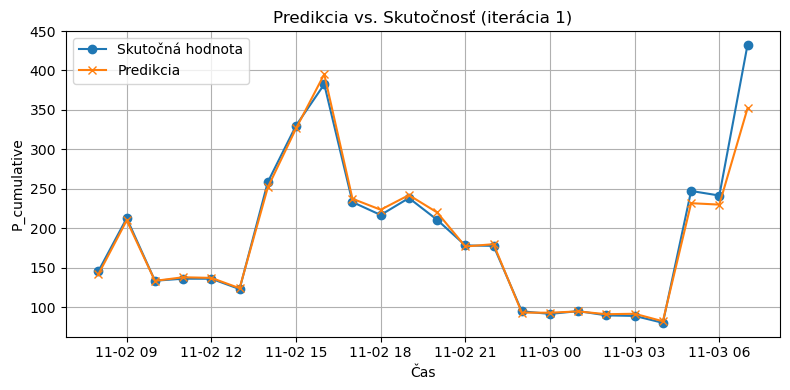


Iterácia 2/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
MAPE iterácie 2: 2.00%
MAE iterácie 2: 3.29


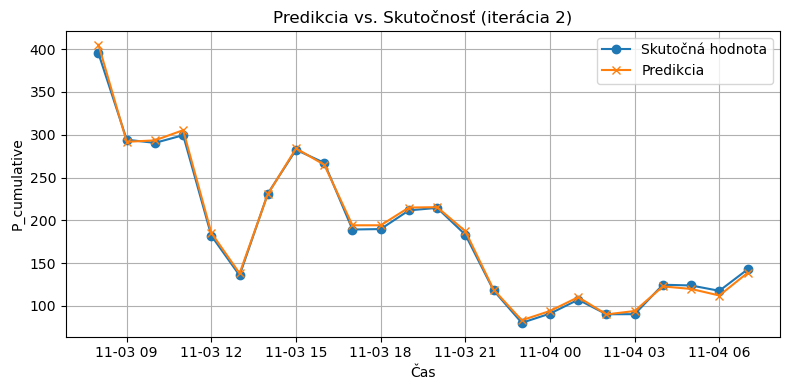


Iterácia 3/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
MAPE iterácie 3: 1.72%
MAE iterácie 3: 2.75


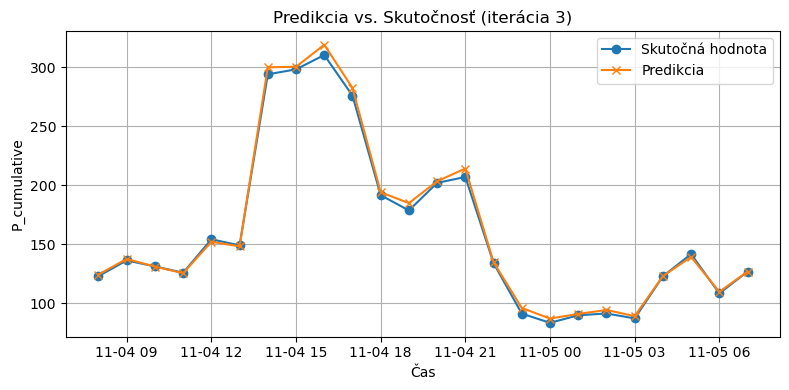


Iterácia 4/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
MAPE iterácie 4: 3.17%
MAE iterácie 4: 6.41


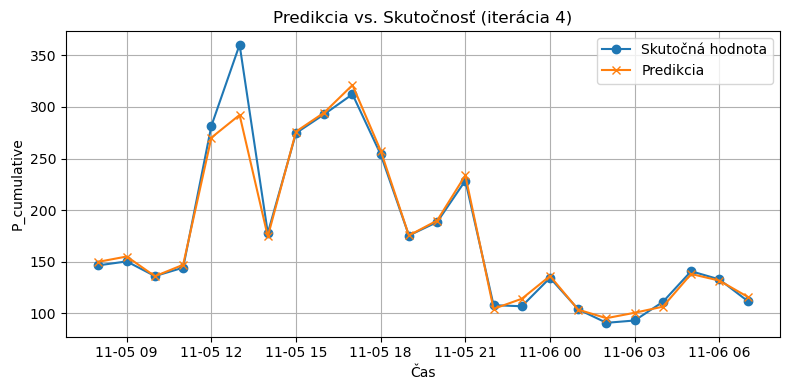


Iterácia 5/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
MAPE iterácie 5: 3.58%
MAE iterácie 5: 5.40


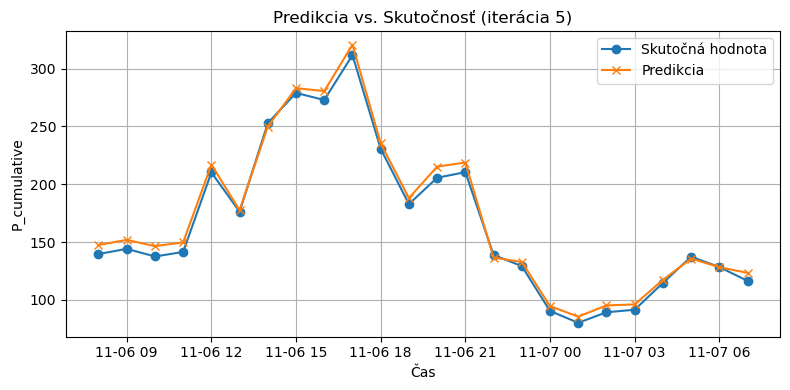


Iterácia 6/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
MAPE iterácie 6: 2.44%
MAE iterácie 6: 4.68


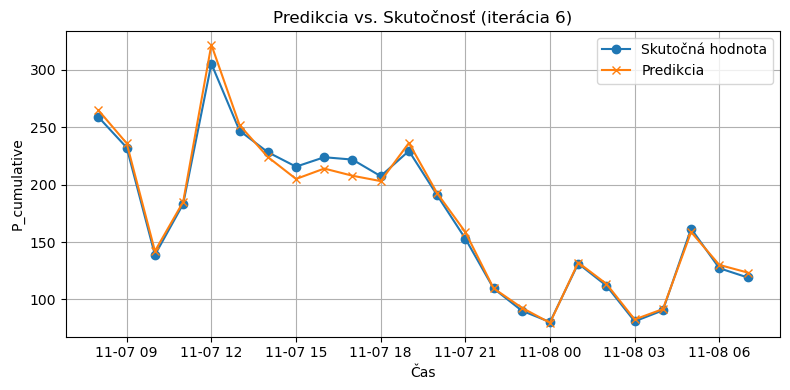


Iterácia 7/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
MAPE iterácie 7: 2.99%
MAE iterácie 7: 6.38


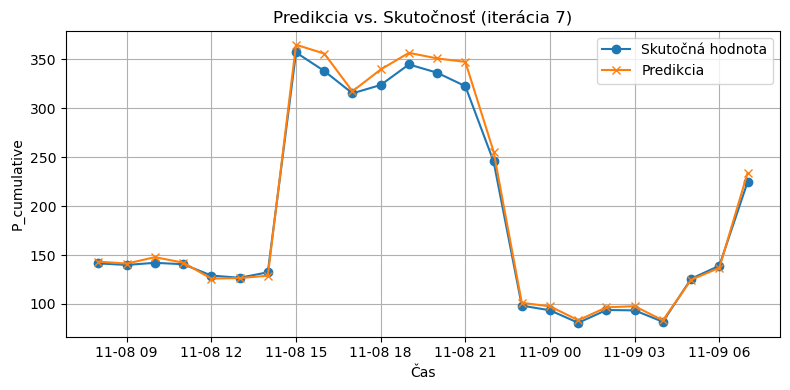


Iterácia 8/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
MAPE iterácie 8: 1.63%
MAE iterácie 8: 2.71


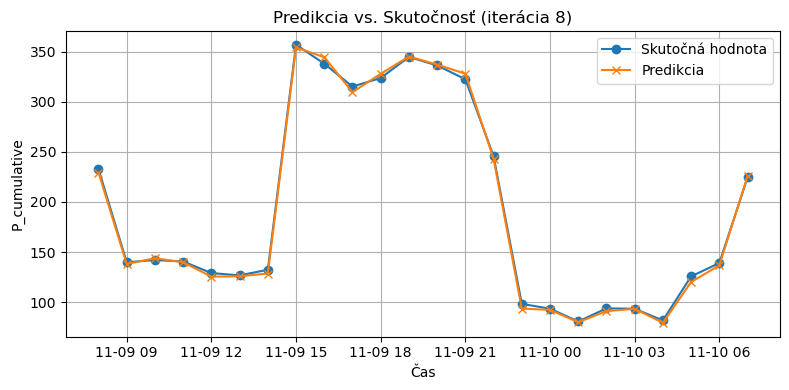


Iterácia 9/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
MAPE iterácie 9: 2.08%
MAE iterácie 9: 3.09


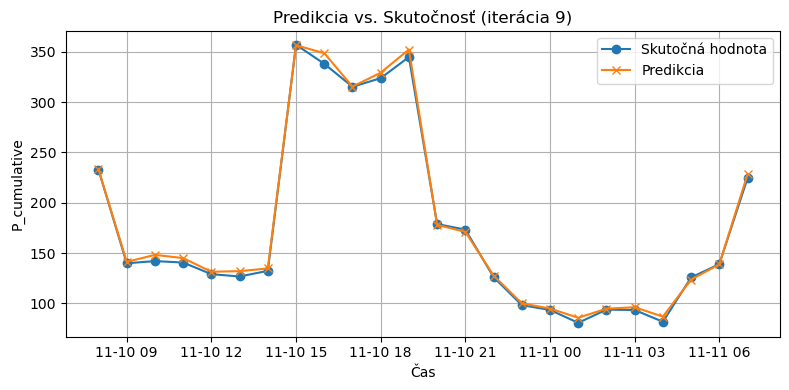


Iterácia 10/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
MAPE iterácie 10: 1.56%
MAE iterácie 10: 3.43


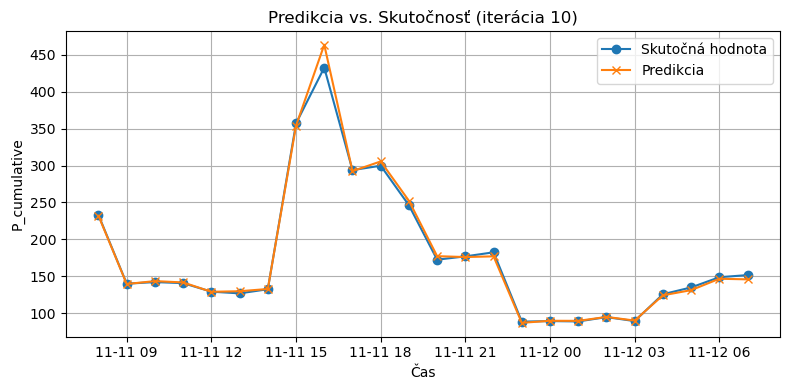


Iterácia 11/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
MAPE iterácie 11: 1.98%
MAE iterácie 11: 3.42


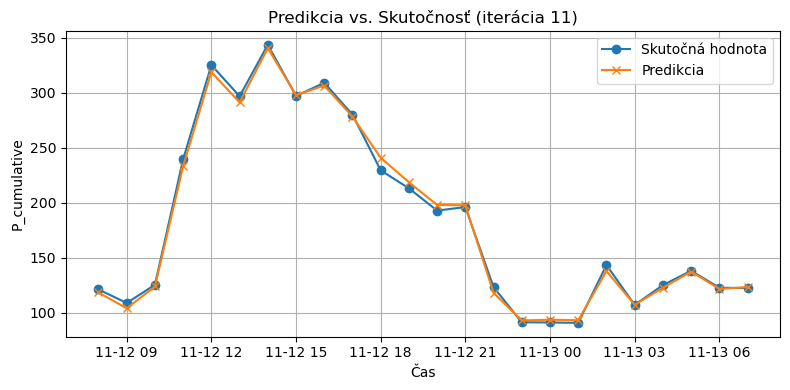


Iterácia 12/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
MAPE iterácie 12: 1.52%
MAE iterácie 12: 3.04


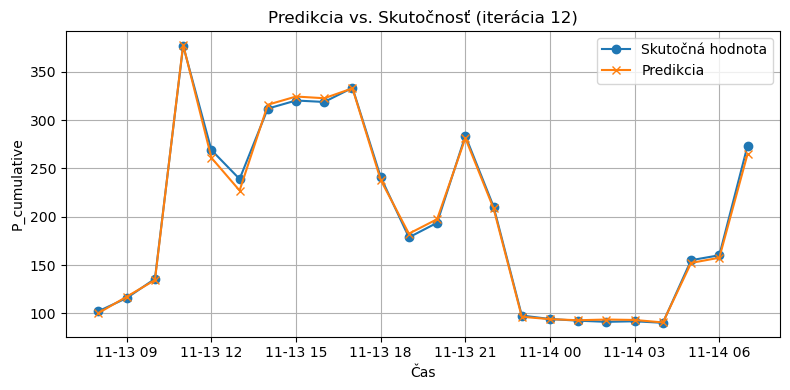


Iterácia 13/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
MAPE iterácie 13: 2.11%
MAE iterácie 13: 4.24


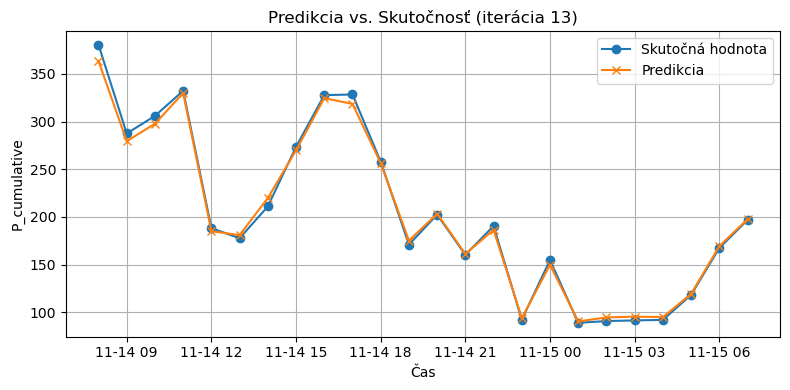


Iterácia 14/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
MAPE iterácie 14: 2.08%
MAE iterácie 14: 4.78


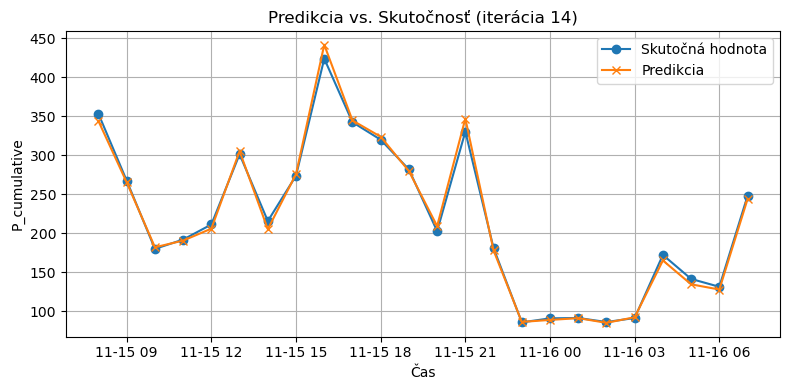


Iterácia 15/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
MAPE iterácie 15: 2.79%
MAE iterácie 15: 8.64


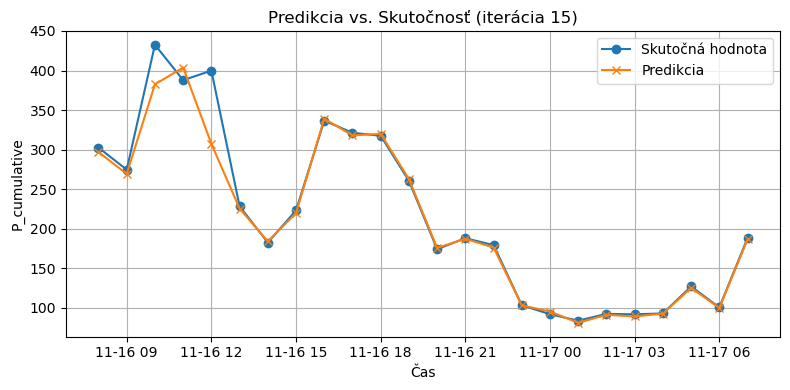


Iterácia 16/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
MAPE iterácie 16: 1.90%
MAE iterácie 16: 3.64


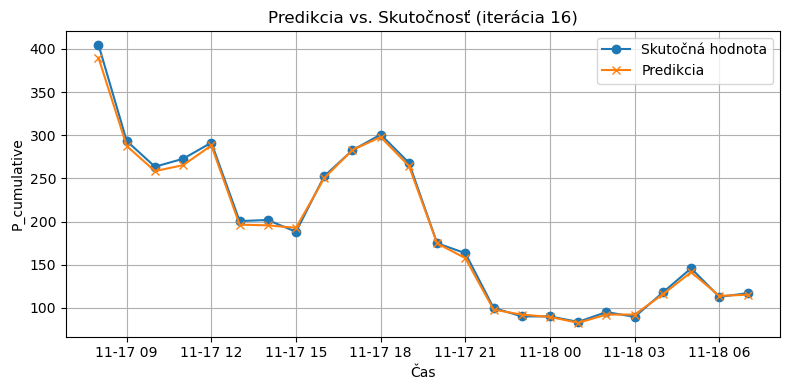


Iterácia 17/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
MAPE iterácie 17: 3.31%
MAE iterácie 17: 3.91


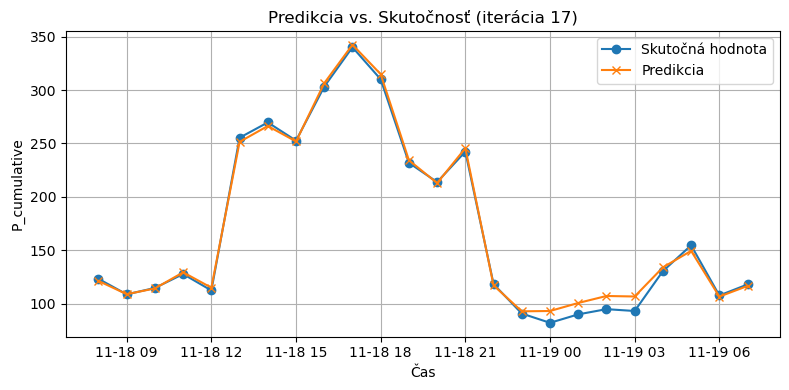


Iterácia 18/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
MAPE iterácie 18: 11.27%
MAE iterácie 18: 13.14


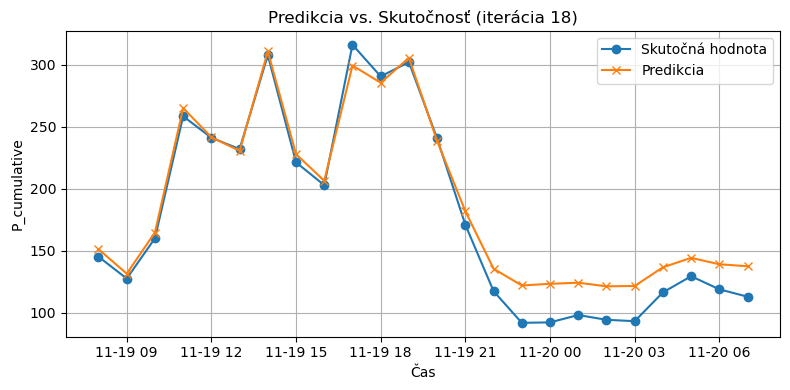


Iterácia 19/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
MAPE iterácie 19: 2.40%
MAE iterácie 19: 3.17


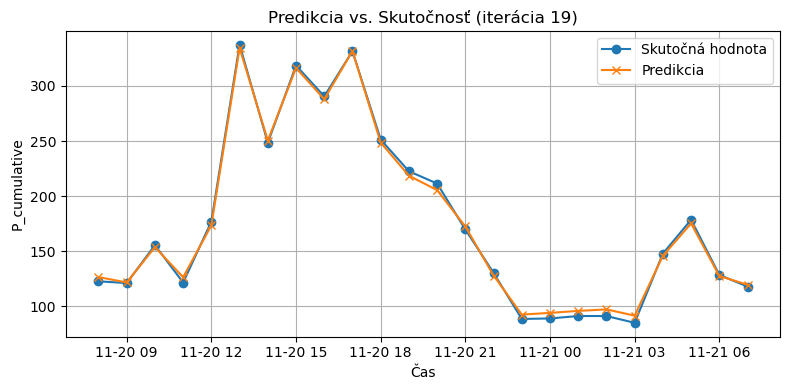


Iterácia 20/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
MAPE iterácie 20: 2.80%
MAE iterácie 20: 4.87


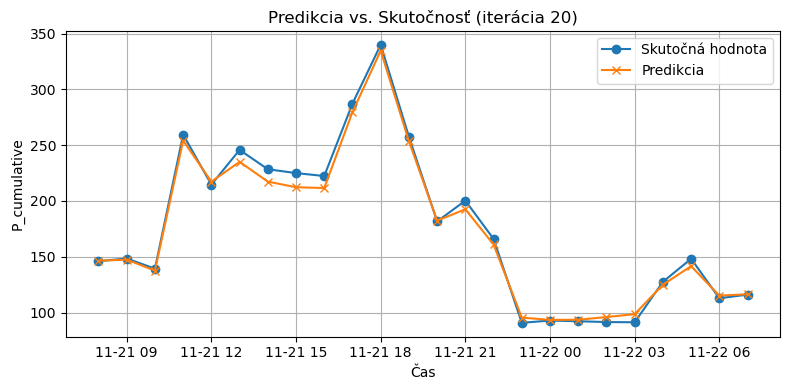


Iterácia 21/21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
MAPE iterácie 21: 3.89%
MAE iterácie 21: 8.96


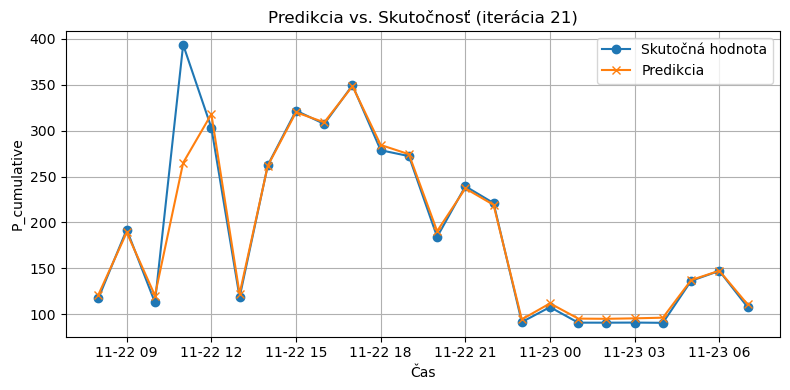


Výsledky po iteráciách:
Priemerné MAPE: 2.86%
Priemerné MAE: 5.11
Minimálne MAPE: 1.52%
Maximálne MAPE: 11.27%
Minimálne MAE: 2.71
Maximálne MAE: 13.14


In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
import warnings

# Potlačenie zbytočných varovaní
warnings.filterwarnings("ignore")

# --- 1. PRÍPRAVA DÁT ---

# Zoznam vstupných atribútov, ktoré sa použijú pri trénovaní modelu
feature_cols = [
    'U_L1', 'U_L2', 'U_L3',       # napätia v troch fázach
    'I_L1', 'I_L2', 'I_L3',       # prúdy v troch fázach
    'P_L1', 'P_L2', 'P_L3',       # činný výkon v troch fázach
    'Q_L1', 'Q_L2', 'Q_L3',       # jalový výkon v troch fázach
    'hour',                       # hodina v rámci dňa
    'lag_1', 'lag_24'             # oneskorené hodnoty cieľa o 1h a 24h
]

# Cieľová premenná – akumulovaný výkon, ktorý sa predikuje
target_col = 'P_cumulative'

# Odstránenie riadkov s chýbajúcimi hodnotami v atribútoch alebo cieľovej premennej
df2 = df2.dropna(subset=feature_cols + [target_col])

# --- 2. PARAMETRE PREDIKCIE ---

train_days = 7            # Dĺžka trénovacieho obdobia (v dňoch)
test_days = 1             # Dĺžka testovacieho obdobia (v dňoch)
total_iterations = 21     # Počet iterácií posuvného okna
mape_list = []            # Zoznam pre uloženie MAPE chýb
mae_list = []             # Zoznam pre uloženie MAE chýb

# --- 3. POSUVNÉ OKNO & TRÉNOVANIE MODELU ---

for i in range(total_iterations):
    print(f"\nIterácia {i+1}/{total_iterations}")

    # Výpočet časového okna pre trénovanie a testovanie
    start_i = df2.index[0] + pd.Timedelta(days=i)
    train_end_i = start_i + pd.Timedelta(days=train_days)
    test_end_i = train_end_i + pd.Timedelta(days=test_days)

    # Výber dát podľa časového okna
    train_i = df2.loc[(df2.index >= start_i) & (df2.index < train_end_i)]
    test_i = df2.loc[(df2.index >= train_end_i) & (df2.index < test_end_i)]

    # Ak má testovacia množina menej ako 24 hodín, iterácia sa preskočí
    if len(test_i) < 24:
        print("Preskočená iterácia kvôli nedostatku dát.")
        continue

    # --- 4. NORMALIZÁCIA ---

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    # Normalizácia vstupov a výstupov na rozsah <0, 1>
    X_train = scaler_X.fit_transform(train_i[feature_cols])
    y_train = scaler_y.fit_transform(train_i[[target_col]])
    X_test = scaler_X.transform(test_i[feature_cols])
    y_test = scaler_y.transform(test_i[[target_col]])

    # Preusporiadanie dát do tvaru (vzorky, časové kroky, vstupy) pre LSTM
    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

    # --- 5. DEFINOVANIE A TRÉNOVANIE LSTM MODELU ---

    model = Sequential()
    model.add(LSTM(100, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))  # LSTM vrstva
    model.add(Dense(1))  # Výstupná vrstva – predikcia jednej hodnoty
    model.compile(optimizer='adam', loss='mse')  # Optimalizácia a funkcia straty
    model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)  # Tréning modelu

    # --- 6. PREDIKCIA A INVERZNÉ ŠKÁLOVANIE ---

    y_pred = model.predict(X_test)  # Predikcia
    y_pred_inv = scaler_y.inverse_transform(y_pred)  # Prevod späť na pôvodnú mierku
    y_test_inv = scaler_y.inverse_transform(y_test)  # Skutočné hodnoty späť na pôvodnú mierku

    # --- 7. VYHODNOTENIE PRESNOSTI ---

    mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mape_list.append(mape)
    mae_list.append(mae)

    print(f"MAPE iterácie {i+1}: {mape * 100:.2f}%")
    print(f"MAE iterácie {i+1}: {mae:.2f}")

    # --- 8. VIZUALIZÁCIA: GRAF PREDIKCIE A SKUTOČNOSTI ---

    plt.figure(figsize=(8, 4))
    plt.plot(test_i.index, y_test_inv, label='Skutočná hodnota', marker='o')
    plt.plot(test_i.index, y_pred_inv, label='Predikcia', marker='x')
    plt.title(f'Predikcia vs. Skutočnosť (iterácia {i+1})')
    plt.xlabel('Čas')
    plt.ylabel('P_cumulative')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- 9. SUMARIZÁCIA CELKOVÝCH VÝSLEDKOV ---

print("\nVýsledky po iteráciách:")
print(f"Priemerné MAPE: {np.mean(mape_list) * 100:.2f}%")     # Priemerná percentuálna chyba
print(f"Priemerné MAE: {np.mean(mae_list):.2f}")              # Priemerná absolútna chyba
print(f"Minimálne MAPE: {np.min(mape_list) * 100:.2f}%")      # Najnižšia MAPE
print(f"Maximálne MAPE: {np.max(mape_list) * 100:.2f}%")      # Najvyššia MAPE
print(f"Minimálne MAE: {np.min(mae_list):.2f}")               # Najnižšia MAE
print(f"Maximálne MAE: {np.max(mae_list):.2f}")               # Najvyššia MAE



Iterácia 1/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
MAPE iterácie 1: 1.72%
MAE iterácie 1: 2.58


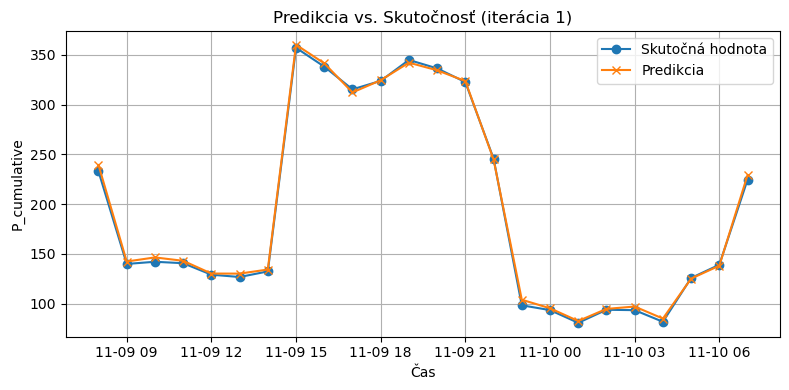


Iterácia 2/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
MAPE iterácie 2: 1.73%
MAE iterácie 2: 2.52


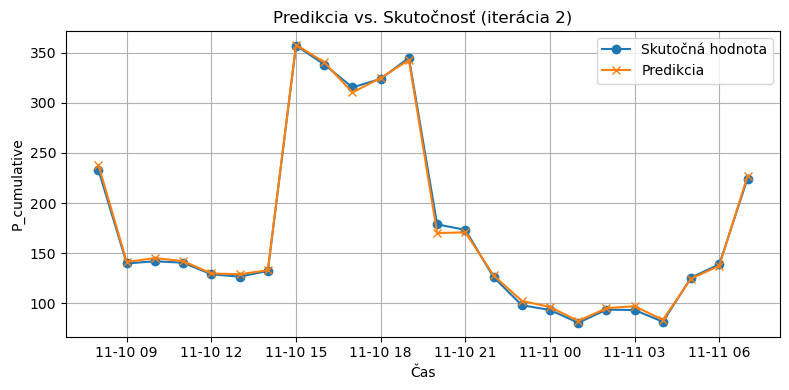


Iterácia 3/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
MAPE iterácie 3: 1.76%
MAE iterácie 3: 3.59


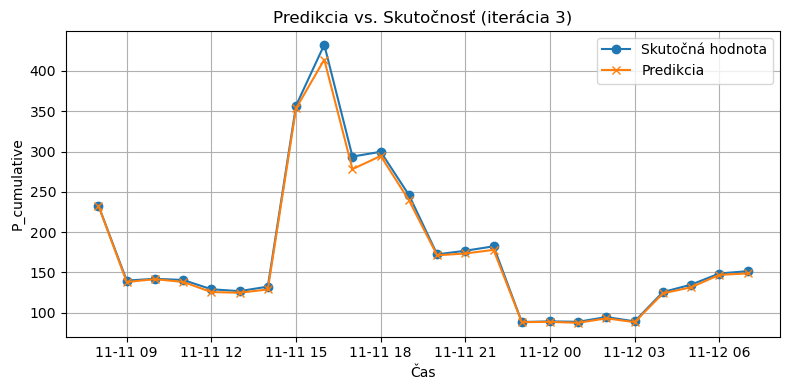


Iterácia 4/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
MAPE iterácie 4: 3.64%
MAE iterácie 4: 6.27


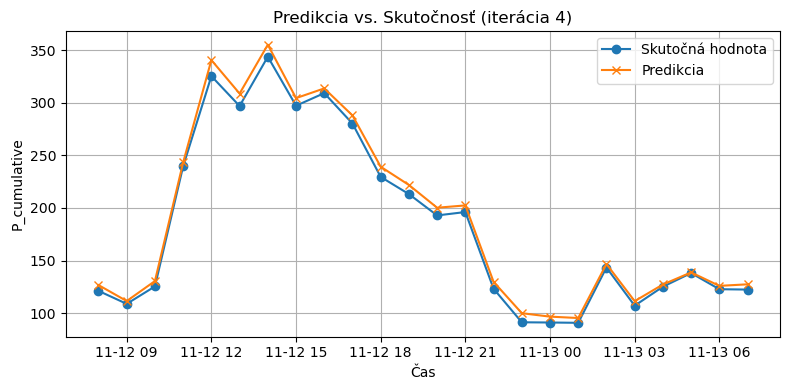


Iterácia 5/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
MAPE iterácie 5: 1.45%
MAE iterácie 5: 3.26


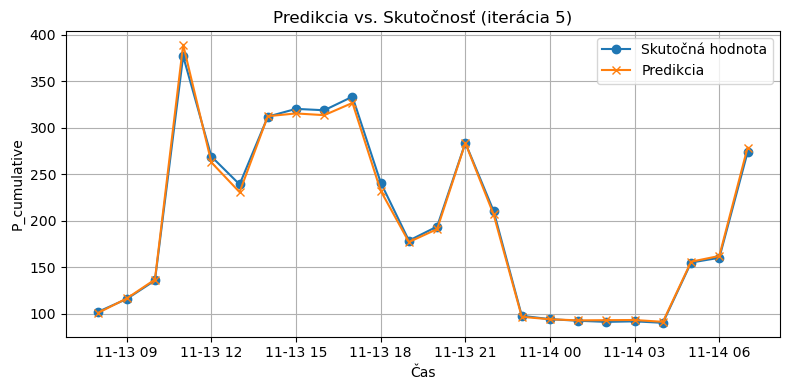


Iterácia 6/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
MAPE iterácie 6: 1.74%
MAE iterácie 6: 3.78


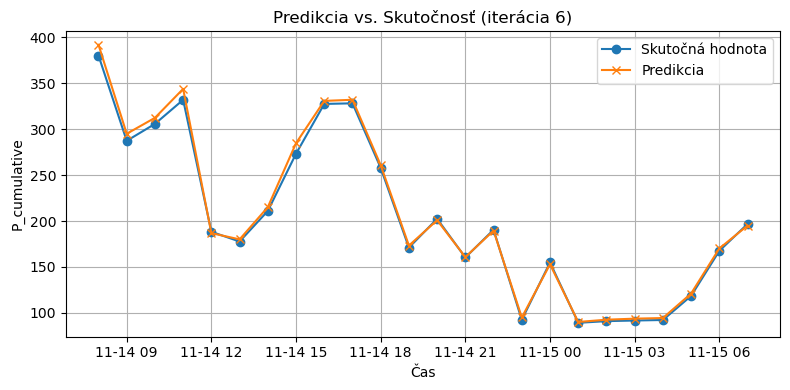


Iterácia 7/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
MAPE iterácie 7: 2.80%
MAE iterácie 7: 4.50


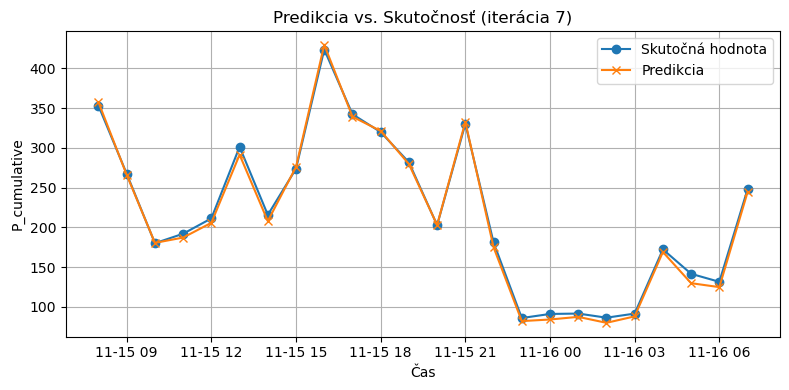


Iterácia 8/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
MAPE iterácie 8: 3.09%
MAE iterácie 8: 9.63


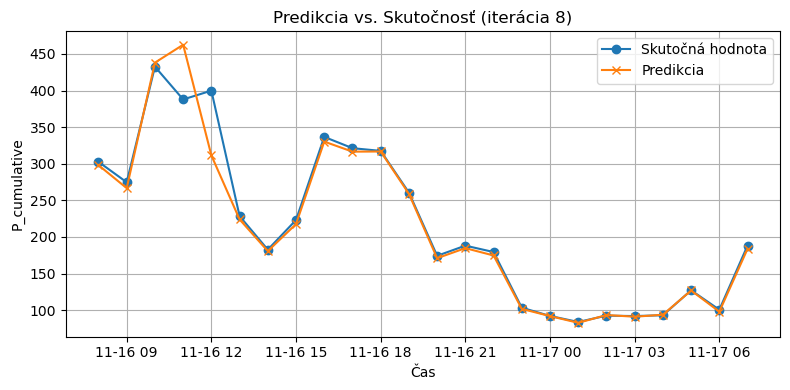


Iterácia 9/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
MAPE iterácie 9: 1.58%
MAE iterácie 9: 3.00


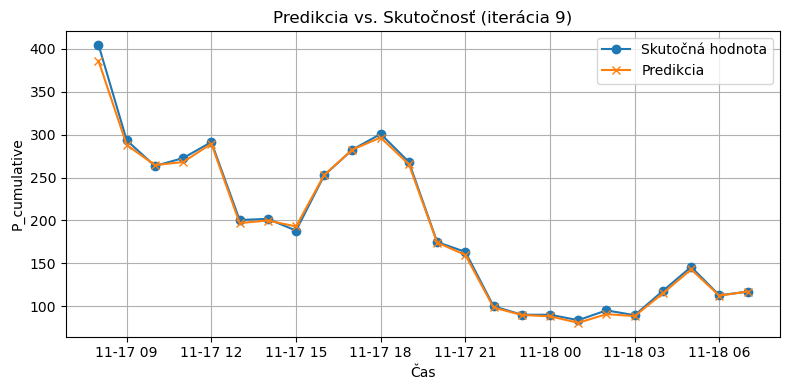


Iterácia 10/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
MAPE iterácie 10: 2.99%
MAE iterácie 10: 3.31


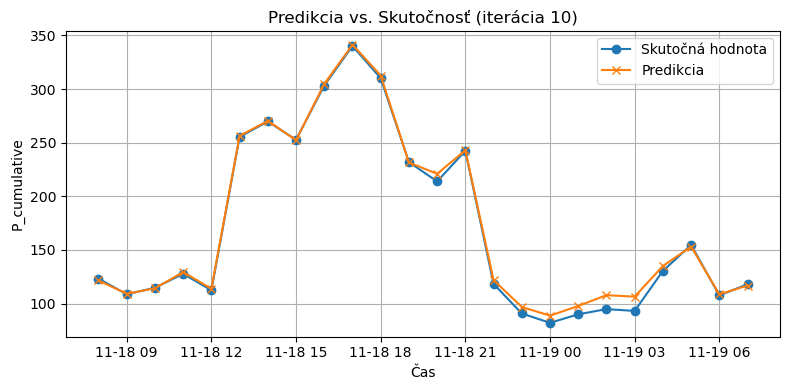


Iterácia 11/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
MAPE iterácie 11: 5.06%
MAE iterácie 11: 7.55


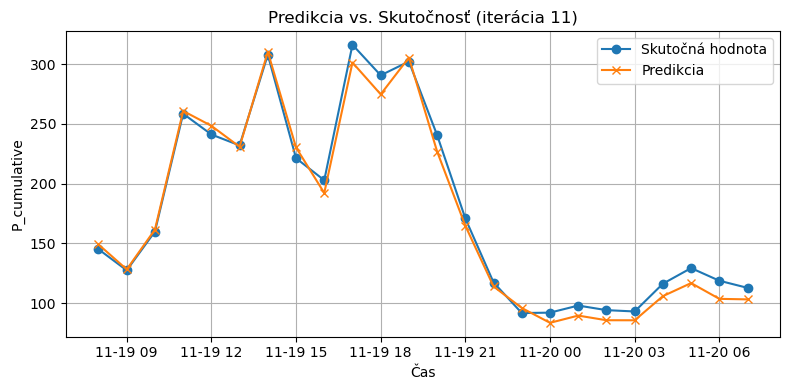


Iterácia 12/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
MAPE iterácie 12: 2.27%
MAE iterácie 12: 3.17


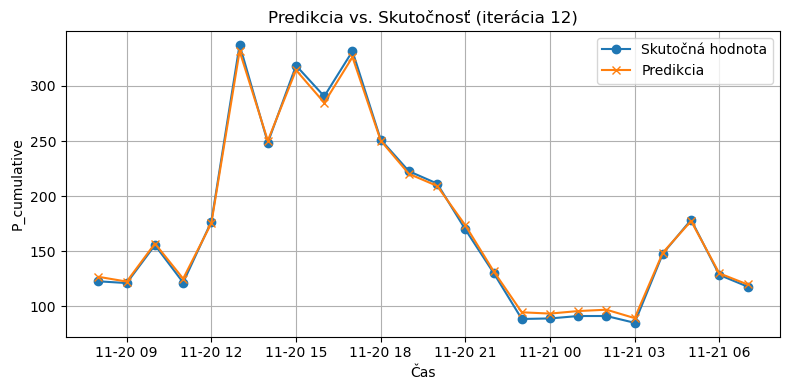


Iterácia 13/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
MAPE iterácie 13: 1.43%
MAE iterácie 13: 2.40


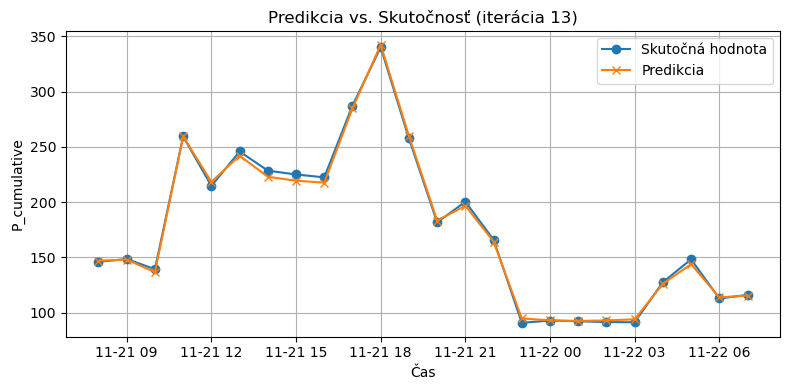


Iterácia 14/14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
MAPE iterácie 14: 2.71%
MAE iterácie 14: 7.29


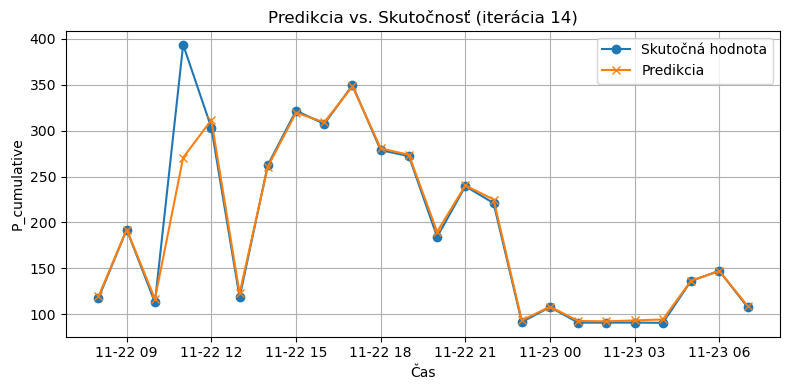


Výsledky po iteráciách:
Priemerné MAPE: 2.43%
Priemerné MAE: 4.49
Minimálne MAPE: 1.43%
Maximálne MAPE: 5.06%
Minimálne MAE: 2.40
Maximálne MAE: 9.63


In [38]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


# Zoznam vstupných atribútov
feature_cols = [
    'U_L1', 'U_L2', 'U_L3',
    'I_L1', 'I_L2', 'I_L3',
    'P_L1', 'P_L2', 'P_L3',
    'Q_L1', 'Q_L2', 'Q_L3',
    'hour',
    'lag_1', 'lag_24'
]

target_col = 'P_cumulative'

# Odstránenie NaN hodnôt
df2 = df2.dropna(subset=feature_cols + [target_col])

# Parametre
train_days = 14
test_days = 1
total_iterations = 14
mape_list = []
mae_list = []

# Iteračný cyklus
for i in range(total_iterations):
    print(f"\nIterácia {i+1}/{total_iterations}")

    start_i = df2.index[0] + pd.Timedelta(days=i)
    train_end_i = start_i + pd.Timedelta(days=train_days)
    test_end_i = train_end_i + pd.Timedelta(days=test_days)

    train_i = df2.loc[(df2.index >= start_i) & (df2.index < train_end_i)]
    test_i = df2.loc[(df2.index >= train_end_i) & (df2.index < test_end_i)]

    if len(test_i) < 24:
        print("Preskočená iterácia kvôli nedostatku dát.")
        continue

    # Normalizácia
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train = scaler_X.fit_transform(train_i[feature_cols])
    y_train = scaler_y.fit_transform(train_i[[target_col]])
    X_test = scaler_X.transform(test_i[feature_cols])
    y_test = scaler_y.transform(test_i[[target_col]])

    # Reshape pre LSTM
    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

    # LSTM model
    model = Sequential()
    model.add(LSTM(100, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

    # Predikcia
    y_pred = model.predict(X_test)
    y_pred_inv = scaler_y.inverse_transform(y_pred)
    y_test_inv = scaler_y.inverse_transform(y_test)

    # Vyhodnotenie
    mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mape_list.append(mape)
    mae_list.append(mae)

    print(f"MAPE iterácie {i+1}: {mape * 100:.2f}%")
    print(f"MAE iterácie {i+1}: {mae:.2f}")

    # Graf 1: Predikcia vs. skutočnosť
    plt.figure(figsize=(8, 4))
    plt.plot(test_i.index, y_test_inv, label='Skutočná hodnota', marker='o')
    plt.plot(test_i.index, y_pred_inv, label='Predikcia', marker='x')
    plt.title(f'Predikcia vs. Skutočnosť (iterácia {i+1})')
    plt.xlabel('Čas')
    plt.ylabel('P_cumulative')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Zhrnutie výsledkov
print("\nVýsledky po iteráciách:")
print(f"Priemerné MAPE: {np.mean(mape_list) * 100:.2f}%")
print(f"Priemerné MAE: {np.mean(mae_list):.2f}")
print(f"Minimálne MAPE: {np.min(mape_list) * 100:.2f}%")
print(f"Maximálne MAPE: {np.max(mape_list) * 100:.2f}%")
print(f"Minimálne MAE: {np.min(mae_list):.2f}")
print(f"Maximálne MAE: {np.max(mae_list):.2f}")



Iterácia 1/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
MAPE iterácie 1: 2.38%
MAE iterácie 1: 7.69


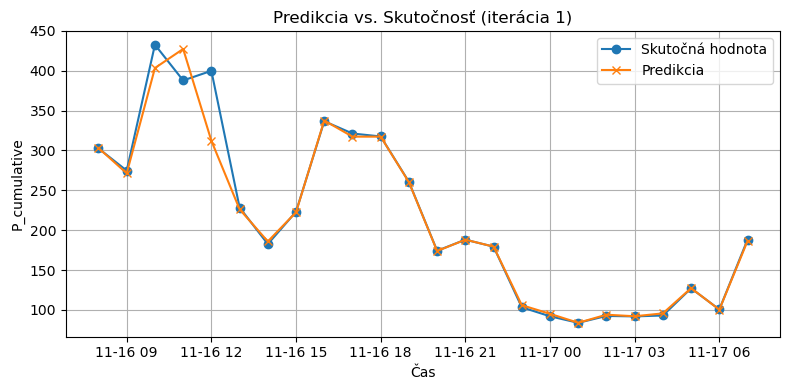


Iterácia 2/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
MAPE iterácie 2: 1.34%
MAE iterácie 2: 1.86


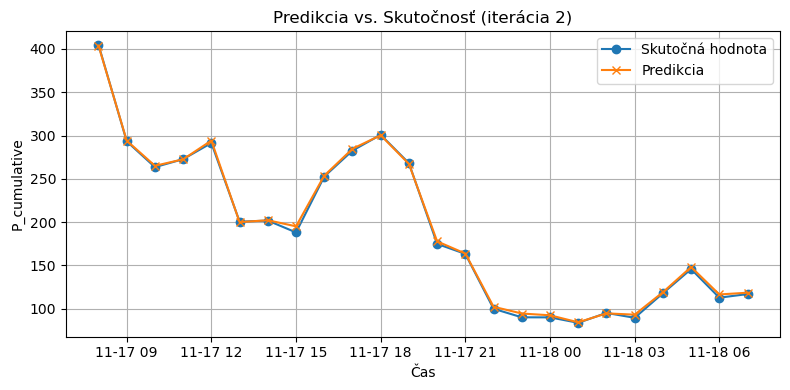


Iterácia 3/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
MAPE iterácie 3: 3.15%
MAE iterácie 3: 3.55


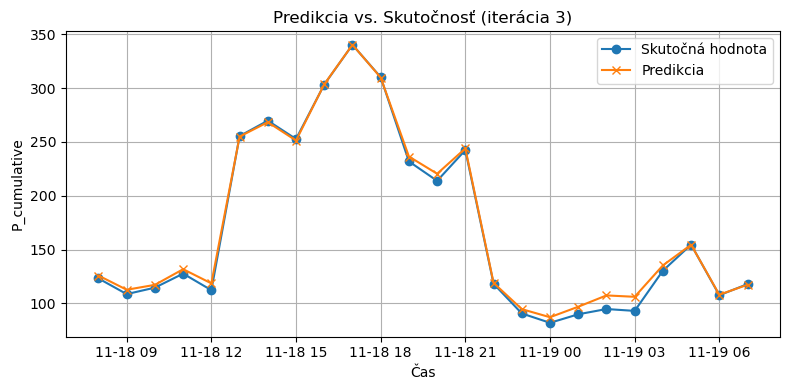


Iterácia 4/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
MAPE iterácie 4: 11.67%
MAE iterácie 4: 14.77


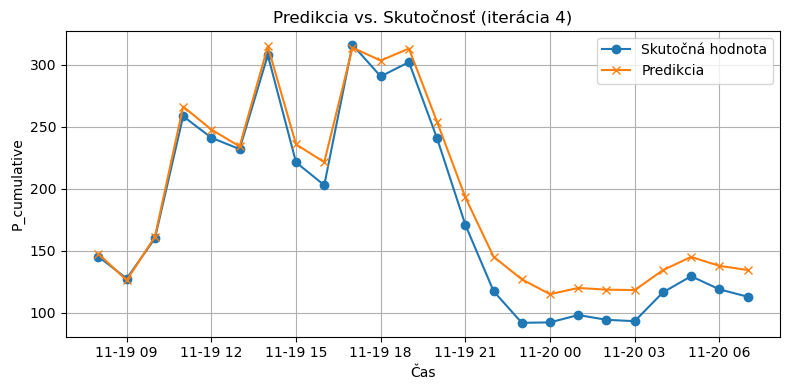


Iterácia 5/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
MAPE iterácie 5: 4.70%
MAE iterácie 5: 6.47


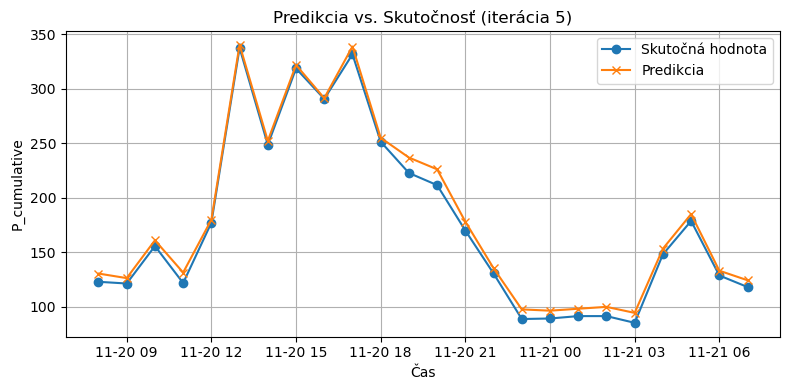


Iterácia 6/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
MAPE iterácie 6: 2.28%
MAE iterácie 6: 4.04


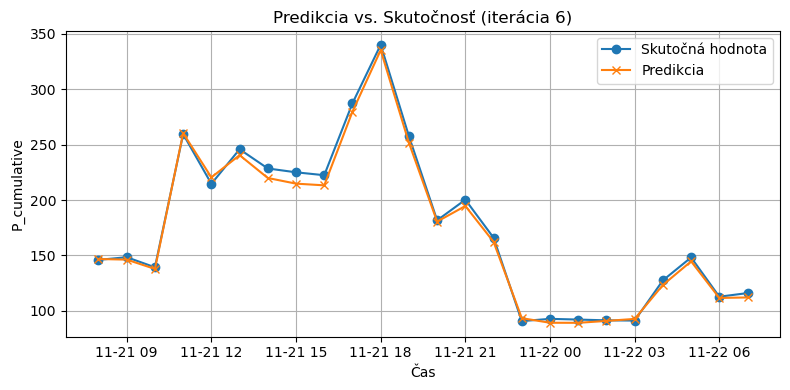


Iterácia 7/7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
MAPE iterácie 7: 3.27%
MAE iterácie 7: 8.40


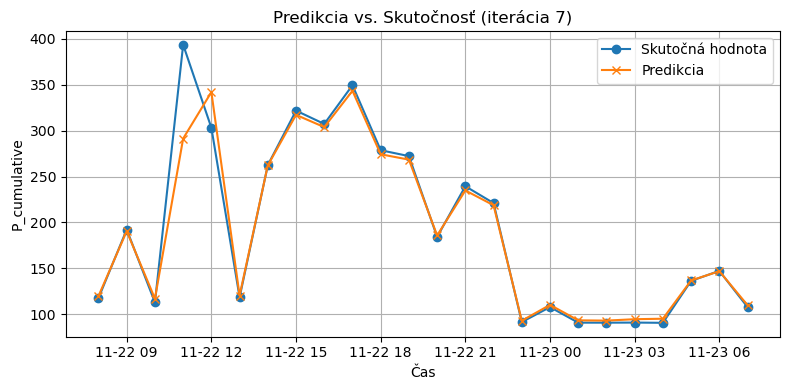


Výsledky po iteráciách:
Priemerné MAPE: 4.11%
Priemerné MAE: 6.68
Minimálne MAPE: 1.34%
Maximálne MAPE: 11.67%
Minimálne MAE: 1.86
Maximálne MAE: 14.77


In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


# Zoznam vstupných atribútov
feature_cols = [
    'U_L1', 'U_L2', 'U_L3',
    'I_L1', 'I_L2', 'I_L3',
    'P_L1', 'P_L2', 'P_L3',
    'Q_L1', 'Q_L2', 'Q_L3',
    'hour',
    'lag_1', 'lag_24'
]

target_col = 'P_cumulative'

# Odstránenie NaN hodnôt (preistotu)
df2 = df2.dropna(subset=feature_cols + [target_col])

# Parametre
train_days = 21
test_days = 1
total_iterations = 7
mape_list = []
mae_list = []

# Iteračný cyklus
for i in range(total_iterations):
    print(f"\nIterácia {i+1}/{total_iterations}")

    start_i = df2.index[0] + pd.Timedelta(days=i)
    train_end_i = start_i + pd.Timedelta(days=train_days)
    test_end_i = train_end_i + pd.Timedelta(days=test_days)

    train_i = df2.loc[(df2.index >= start_i) & (df2.index < train_end_i)]
    test_i = df2.loc[(df2.index >= train_end_i) & (df2.index < test_end_i)]

    # poistka
    if len(test_i) < 24:
        print("Preskočená iterácia kvôli nedostatku dát.")
        continue

    # Normalizácia
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train = scaler_X.fit_transform(train_i[feature_cols])
    y_train = scaler_y.fit_transform(train_i[[target_col]])
    X_test = scaler_X.transform(test_i[feature_cols])
    y_test = scaler_y.transform(test_i[[target_col]])

    # Reshape pre LSTM
    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

    # LSTM model
    model = Sequential()
    model.add(LSTM(100, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train, y_train, epochs=30, batch_size=8, verbose=0)

    # Predikcia
    y_pred = model.predict(X_test)
    y_pred_inv = scaler_y.inverse_transform(y_pred)
    y_test_inv = scaler_y.inverse_transform(y_test)

    # Vyhodnotenie
    mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mape_list.append(mape)
    mae_list.append(mae)

    print(f"MAPE iterácie {i+1}: {mape * 100:.2f}%")
    print(f"MAE iterácie {i+1}: {mae:.2f}")

    # Graf 1: Predikcia vs. skutočnosť
    plt.figure(figsize=(8, 4))
    plt.plot(test_i.index, y_test_inv, label='Skutočná hodnota', marker='o')
    plt.plot(test_i.index, y_pred_inv, label='Predikcia', marker='x')
    plt.title(f'Predikcia vs. Skutočnosť (iterácia {i+1})')
    plt.xlabel('Čas')
    plt.ylabel('P_cumulative')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Zhrnutie výsledkov
print("\nVýsledky po iteráciách:")
print(f"Priemerné MAPE: {np.mean(mape_list) * 100:.2f}%")
print(f"Priemerné MAE: {np.mean(mae_list):.2f}")
print(f"Minimálne MAPE: {np.min(mape_list) * 100:.2f}%")
print(f"Maximálne MAPE: {np.max(mape_list) * 100:.2f}%")
print(f"Minimálne MAE: {np.min(mae_list):.2f}")
print(f"Maximálne MAE: {np.max(mae_list):.2f}")


### Optimalizácia pomocou GridSearch

Na účely optimalizácie modelu sme vytvorili vlastný, jednoduchý GridSearch algoritmus, ktorý prechádzal všetky možné kombinácie vybraných hyperparametrov (`units`, `epochs`, `batch_size`).  
Každá kombinácia bola testovaná v **piatich po sebe idúcich časových iteráciách**, s rôznou dĺžkou trvania tréningu:

- **7 dní** tréning / 1 deň testovanie  
- **14 dní** tréning / 1 deň testovanie  
- **21 dní** tréning / 1 deň testovanie

Pri každej iterácii sme zaznamenávali hodnoty **MAPE** a **MAE**, pričom výsledné skóre pre danú kombináciu predstavoval **priemer z piatich opakovaní**.

Na základe týchto experimentov bola vytvorená prehľadná tabuľka výsledkov, z ktorej sme vybrali **kombináciu s najnižšími hodnotami MAPE a MAE**.  
Táto optimálna konfigurácia bola následne použitá ako **pevné nastavenie pre všetky ďalšie experimenty**.


In [44]:
import pandas as pd
import numpy as np
import itertools
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Zoradenie dát podľa indexu, nastavenie hodinovej frekvencie a odstránenie chýbajúcich hodnôt
df2 = df2.sort_index().asfreq('H').dropna()

# Výber vstupných atribútov (feature columns)
feature_cols = [
    'U_L1', 'U_L2', 'U_L3',       # napätia fáz
    'I_L1', 'I_L2', 'I_L3',       # prúdy fáz
    'P_L1', 'P_L2', 'P_L3',       # činný výkon fáz
    'Q_L1', 'Q_L2', 'Q_L3',       # jalový výkon fáz
    'hour',                       # hodina dňa ako doplnkový atribút
    'lag_1', 'lag_24'             # oneskorené hodnoty cieľa (napr. 1 hod. a 24 hod. späť)
]

# Cieľová premenná, ktorú sa snažíme predikovať
target_col = 'P_cumulative'

# Definovanie parametrov pre GridSearch (kombinácie jednotiek, epôch a batch size)
param_grid = {
    'units': [50, 100],
    'epochs': [30, 50],
    'batch_size': [8, 16]
}
# Všetky kombinácie parametrov
param_combinations = list(itertools.product(
    param_grid['units'],
    param_grid['epochs'],
    param_grid['batch_size']
))

# Nastavenie dĺžky trénovacieho a testovacieho obdobia
train_days = 7      # 7 dní trénovanie
test_days = 1       # 1 deň testovanie
total_iterations = 5  # počet iterácií (posun o 1 deň v každej iterácii)
results = []        # zoznam na uloženie výsledkov pre každú kombináciu

# Hlavný cyklus cez všetky kombinácie parametrov
for units, epochs, batch_size in param_combinations:
    print(f"\nTestujem: units={units}, epochs={epochs}, batch_size={batch_size}")
    mape_list = []  # zoznam MAPE chýb pre každú iteráciu
    mae_list = []   # zoznam MAE chýb pre každú iteráciu

    # Posuvné okno cez časové obdobia
    for i in range(total_iterations):
        start_i = df2.index[0] + pd.Timedelta(days=i)
        train_end_i = start_i + pd.Timedelta(days=train_days)
        test_end_i = train_end_i + pd.Timedelta(days=test_days)

        # Vytvorenie trénovacích a testovacích množín
        train_i = df2.loc[(df2.index >= start_i) & (df2.index < train_end_i)]
        test_i = df2.loc[(df2.index >= train_end_i) & (df2.index < test_end_i)]

        # Ak testovacia množina nemá 24 hodín, preskoč iteráciu
        if len(test_i) < 24:
            continue

        # Škálovanie vstupov a cieľa
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        X_train = scaler_X.fit_transform(train_i[feature_cols])
        y_train = scaler_y.fit_transform(train_i[[target_col]])
        X_test = scaler_X.transform(test_i[feature_cols])
        y_test = scaler_y.transform(test_i[[target_col]])

        # Preusporiadanie tvaru dát pre LSTM: (vzorky, kroky, vstupy)
        X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
        X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

        # Definovanie LSTM modelu
        model = Sequential()
        model.add(LSTM(units, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dense(1))  # výstupná vrstva s jedným neurónom
        model.compile(optimizer='adam', loss='mse')  # optimalizátor a funkcia straty
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)  # trénovanie modelu

        # Predikcia a spätné škálovanie výstupov
        y_pred = model.predict(X_test)
        y_pred_inv = scaler_y.inverse_transform(y_pred)
        y_test_inv = scaler_y.inverse_transform(y_test)

        # Výpočet metrík MAPE a MAE
        mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
        mae = mean_absolute_error(y_test_inv, y_pred_inv)
        mape_list.append(mape)
        mae_list.append(mae)

    # Uloženie priemerných metrík pre danú kombináciu parametrov
    results.append({
        'units': units,
        'epochs': epochs,
        'batch_size': batch_size,
        'avg_mape': np.mean(mape_list),
        'avg_mae': np.mean(mae_list)
    })

# Výpis výsledkov ako DataFrame a zoradenie podľa priemernej MAPE
df_results = pd.DataFrame(results)
print("\nVýsledky Grid Searchu:")
print(df_results.sort_values(by='avg_mape'))



Testujem: units=50, epochs=30, batch_size=8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step

Testujem: units=50, epochs=30, batch_size=16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step

Testujem: units=50, epochs=50, batch_size=8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step

Testujem: units=50, epochs=50, batch_size=16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step

Testujem: units=100, epochs=30, batch

In [46]:
import pandas as pd
import numpy as np
import itertools
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Načítanie a príprava dát
# Zoradenie podľa indexu, nastavenie hodinovej frekvencie a odstránenie chýbajúcich hodnôt
df2 = df2.sort_index().asfreq('H').dropna()

# Výber vstupných atribútov
feature_cols = [
    'U_L1', 'U_L2', 'U_L3',       # napätia fáz
    'I_L1', 'I_L2', 'I_L3',       # prúdy fáz
    'P_L1', 'P_L2', 'P_L3',       # činný výkon fáz
    'Q_L1', 'Q_L2', 'Q_L3',       # jalový výkon fáz
    'hour',                       # hodina ako doplnkový atribút
    'lag_1', 'lag_24'             # oneskorené hodnoty cieľa (lagy)
]

# Cieľová premenná (výkon kumulatívne)
target_col = 'P_cumulative'

# GridSearch – kombinácie parametrov pre LSTM model
param_grid = {
    'units': [50, 100],          # počet jednotiek v LSTM vrstve
    'epochs': [30, 50],          # počet epôch pre trénovanie
    'batch_size': [8, 16]        # veľkosť batchu
}

# Vygenerovanie všetkých možných kombinácií parametrov
param_combinations = list(itertools.product(
    param_grid['units'],
    param_grid['epochs'],
    param_grid['batch_size']
))

# Dĺžka trénovacieho a testovacieho obdobia
train_days = 14       # trénujeme na 14 dňoch
test_days = 1         # testujeme na 1 dni
total_iterations = 5  # vykonáme 5 posuvných iterácií
results = []          # výsledky sa uložia sem

# Pre každú kombináciu parametrov trénujeme a testujeme model
for units, epochs, batch_size in param_combinations:
    print(f"\nTestujem: units={units}, epochs={epochs}, batch_size={batch_size}")
    mape_list = []  # uloženie chýb pre MAPE
    mae_list = []   # uloženie chýb pre MAE

    # Posuvné časové okno pre trénovanie/testovanie
    for i in range(total_iterations):
        start_i = df2.index[0] + pd.Timedelta(days=i)
        train_end_i = start_i + pd.Timedelta(days=train_days)
        test_end_i = train_end_i + pd.Timedelta(days=test_days)

        # Výber dát pre danú iteráciu
        train_i = df2.loc[(df2.index >= start_i) & (df2.index < train_end_i)]
        test_i = df2.loc[(df2.index >= train_end_i) & (df2.index < test_end_i)]

        # Ak má testovací set menej ako 24 hodín, preskočíme iteráciu
        if len(test_i) < 24:
            continue

        # Normalizácia vstupov a cieľa
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        # Fitovanie na trénovacích dátach a transformácia
        X_train = scaler_X.fit_transform(train_i[feature_cols])
        y_train = scaler_y.fit_transform(train_i[[target_col]])
        X_test = scaler_X.transform(test_i[feature_cols])
        y_test = scaler_y.transform(test_i[[target_col]])

        # Reshape do tvaru (vzorky, kroky, vstupy) pre LSTM
        X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
        X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

        # Definovanie LSTM modelu
        model = Sequential()
        model.add(LSTM(units, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dense(1))  # výstupná vrstva
        model.compile(optimizer='adam', loss='mse')  # optimalizácia a funkcia straty
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)  # trénovanie modelu

        # Predikcia a spätné škálovanie
        y_pred = model.predict(X_test)
        y_pred_inv = scaler_y.inverse_transform(y_pred)
        y_test_inv = scaler_y.inverse_transform(y_test)

        # Výpočet metrík
        mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
        mae = mean_absolute_error(y_test_inv, y_pred_inv)
        mape_list.append(mape)
        mae_list.append(mae)

    # Uloženie priemerných metrík pre túto kombináciu parametrov
    results.append({
        'units': units,
        'epochs': epochs,
        'batch_size': batch_size,
        'avg_mape': np.mean(mape_list),
        'avg_mae': np.mean(mae_list)
    })

# Výpis výsledkov zoradený podľa MAPE
df_results = pd.DataFrame(results)
print("\nVýsledky Grid Searchu:")
print(df_results.sort_values(by='avg_mape'))



Testujem: units=50, epochs=30, batch_size=8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step

Testujem: units=50, epochs=30, batch_size=16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step

Testujem: units=50, epochs=50, batch_size=8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step

Testujem: units=50, epochs=50, batch_size=16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step

Testujem: units=100, epochs=30, batch

In [60]:
import pandas as pd
import numpy as np
import itertools
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Úprava dát: zoradenie podľa času, nastavenie hodinovej frekvencie, odstránenie NaN hodnôt
df2 = df2.sort_index().asfreq('H').dropna()

# Definovanie vstupných atribútov (feature columns)
feature_cols = [
    'U_L1', 'U_L2', 'U_L3',       # napätia v troch fázach
    'I_L1', 'I_L2', 'I_L3',       # prúdy v troch fázach
    'P_L1', 'P_L2', 'P_L3',       # činný výkon v troch fázach
    'Q_L1', 'Q_L2', 'Q_L3',       # jalový výkon v troch fázach
    'hour',                       # hodina dňa ako doplnkový znak
    'lag_1', 'lag_24'             # oneskorené hodnoty cieľa (1h a 24h dozadu)
]

# Cieľová premenná
target_col = 'P_cumulative'

# Nastavenie GridSearch parametrov – jednotky v LSTM, epóchy a batch veľkosť
param_grid = {
    'units': [50, 100],
    'epochs': [30, 50],
    'batch_size': [8, 16]
}

# Všetky kombinácie parametrov
param_combinations = list(itertools.product(
    param_grid['units'],
    param_grid['epochs'],
    param_grid['batch_size']
))

# Nastavenie dĺžok pre trénovanie a testovanie
train_days = 21        # trénovacie obdobie: 21 dní
test_days = 1          # testovacie obdobie: 1 deň
total_iterations = 5   # počet iterácií s posúvaním okna o 1 deň
results = []           # zoznam pre ukladanie výsledkov

# Hlavný cyklus cez všetky kombinácie parametrov
for units, epochs, batch_size in param_combinations:
    print(f"\nTestujem: units={units}, epochs={epochs}, batch_size={batch_size}")
    mape_list = []  # MAPE pre každú iteráciu
    mae_list = []   # MAE pre každú iteráciu

    # Posuvné okno v čase
    for i in range(total_iterations):
        start_i = df2.index[0] + pd.Timedelta(days=i)
        train_end_i = start_i + pd.Timedelta(days=train_days)
        test_end_i = train_end_i + pd.Timedelta(days=test_days)

        # Výber trénovacích a testovacích dát
        train_i = df2.loc[(df2.index >= start_i) & (df2.index < train_end_i)]
        test_i = df2.loc[(df2.index >= train_end_i) & (df2.index < test_end_i)]

        # Ak nemá testovacia množina aspoň 24 hodín, preskočí sa iterácia
        if len(test_i) < 24:
            continue

        # Škálovanie dát do intervalu <0,1>
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        # Transformácia trénovacích a testovacích dát
        X_train = scaler_X.fit_transform(train_i[feature_cols])
        y_train = scaler_y.fit_transform(train_i[[target_col]])
        X_test = scaler_X.transform(test_i[feature_cols])
        y_test = scaler_y.transform(test_i[[target_col]])

        # Reshape do formátu (vzorky, časové kroky, počet znakov)
        X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
        X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

        # Vytvorenie a trénovanie LSTM modelu
        model = Sequential()
        model.add(LSTM(units, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))  # LSTM vrstva
        model.add(Dense(1))  # výstupná vrstva
        model.compile(optimizer='adam', loss='mse')  # kompilácia modelu
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)  # trénovanie modelu

        # Predikcia a spätné škálovanie výstupov
        y_pred = model.predict(X_test)
        y_pred_inv = scaler_y.inverse_transform(y_pred)
        y_test_inv = scaler_y.inverse_transform(y_test)

        # Výpočet metrík presnosti
        mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
        mae = mean_absolute_error(y_test_inv, y_pred_inv)
        mape_list.append(mape)
        mae_list.append(mae)

    # Uloženie priemerných výsledkov pre danú kombináciu
    results.append({
        'units': units,
        'epochs': epochs,
        'batch_size': batch_size,
        'avg_mape': np.mean(mape_list),
        'avg_mae': np.mean(mae_list)
    })

# Zostavenie výsledkov do tabuľky a zoradenie podľa najlepšej MAPE
df_results = pd.DataFrame(results)
print("\nVýsledky Grid Searchu:")
print(df_results.sort_values(by='avg_mape'))



Testujem: units=50, epochs=30, batch_size=8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step

Testujem: units=50, epochs=30, batch_size=16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step

Testujem: units=50, epochs=50, batch_size=8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step

Testujem: units=50, epochs=50, batch_size=16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step

Testujem: units=100, epochs=30, batch